# Project Type Analysis

What kinds of projects do MPs recommend? How long do different project types take to complete?

**Scope:** 17th Lok Sabha only (full 5-year term, better completion data)

**Key insight:** Recommendation dates and completion dates are in *separate* records. We link them via `ACTIVITY_NAME` to compute completion times.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import sys

sys.path.insert(0, str(Path(".")))
from _config import COLORS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data")

## 1. Data Loading

In [2]:
import tarfile

with tarfile.open(DATA_DIR / "works_ls17.csv.tar.gz", "r:gz") as tar:
    csv_member = [m for m in tar.getmembers() if m.name == "works_ls17.csv"][0]
    df = pd.read_csv(tar.extractfile(csv_member), low_memory=False)

print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Total records: 242,358
Columns: ['tenure_label', 'tenure_id', 'house', 'state_id', 'state_name', 'constituency_id', 'constituency_name', 'mp_id', 'mp_name', 'tile_label', 'ACTIVITY_NAME', 'ACTUAL_AMOUNT', 'ACTUAL_END_DATE', 'ATTACH_ID', 'AVERAGE_RATING', 'CONSTITUENCY', 'CONSTITUENCY_ID', 'FILE_STATUS', 'FLAG', 'IDA_NAME', 'LETTER_NO', 'MP_NAME', 'RECOMMENDATION_DATE', 'RECOMMENDED_AMOUNT', 'STATE_NAME', 'Sno', 'Total_Amt', 'WORK_CATEGORY', 'WORK_DESCRIPTION', 'WORK_ID', 'WORK_RECOMMENDATION_DTL_ID']


In [3]:
print("\nDate column coverage:")
print(f"RECOMMENDATION_DATE: {df['RECOMMENDATION_DATE'].notna().sum():,} ({df['RECOMMENDATION_DATE'].notna().mean()*100:.1f}%)")
print(f"ACTUAL_END_DATE: {df['ACTUAL_END_DATE'].notna().sum():,} ({df['ACTUAL_END_DATE'].notna().mean()*100:.1f}%)")

has_both = df['RECOMMENDATION_DATE'].notna() & df['ACTUAL_END_DATE'].notna()
print(f"\nRecords with BOTH dates: {has_both.sum():,}")


Date column coverage:
RECOMMENDATION_DATE: 186,256 (76.9%)
ACTUAL_END_DATE: 54,431 (22.5%)

Records with BOTH dates: 0


In [4]:
rec_df = df[df['RECOMMENDATION_DATE'].notna()].copy()
comp_df = df[df['ACTUAL_END_DATE'].notna()].copy()

print(f"Records with recommendation dates: {len(rec_df):,}")
print(f"Records with completion dates: {len(comp_df):,}")

Records with recommendation dates: 186,256
Records with completion dates: 54,431


In [5]:
rec_activities = set(rec_df['ACTIVITY_NAME'].dropna())
comp_activities = set(comp_df['ACTIVITY_NAME'].dropna())
matched_activities = rec_activities & comp_activities

print(f"Unique activities with recommendation: {len(rec_activities):,}")
print(f"Unique activities with completion: {len(comp_activities):,}")
print(f"Activities in BOTH (matchable): {len(matched_activities):,}")

Unique activities with recommendation: 91,488
Unique activities with completion: 54,431
Activities in BOTH (matchable): 54,431


In [6]:
rec_lookup = rec_df.groupby('ACTIVITY_NAME').agg({
    'RECOMMENDATION_DATE': 'first',
    'RECOMMENDED_AMOUNT': 'first',
    'WORK_DESCRIPTION': 'first',
    'mp_name': 'first',
    'state_name': 'first',
    'constituency_name': 'first'
}).reset_index()

comp_lookup = comp_df.groupby('ACTIVITY_NAME').agg({
    'ACTUAL_END_DATE': 'first',
    'ACTUAL_AMOUNT': 'first'
}).reset_index()

merged = rec_lookup.merge(comp_lookup, on='ACTIVITY_NAME', how='inner')
print(f"\nMerged records for completion time analysis: {len(merged):,}")


Merged records for completion time analysis: 54,431


In [7]:
merged['rec_date'] = pd.to_datetime(merged['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
merged['comp_date'] = pd.to_datetime(merged['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
merged['days_to_complete'] = (merged['comp_date'] - merged['rec_date']).dt.days

valid_days = merged['days_to_complete'].notna() & (merged['days_to_complete'] > 0)
merged = merged[valid_days].copy()
print(f"Records with valid completion time: {len(merged):,}")
print(f"\nCompletion time stats (days):")
print(merged['days_to_complete'].describe())

Records with valid completion time: 53,348

Completion time stats (days):
count    53348.000000
mean       520.308165
std        293.237369
min          1.000000
25%        212.000000
50%        602.000000
75%        744.000000
max       7492.000000
Name: days_to_complete, dtype: float64


## 2. Build Project Taxonomy

Keyword-based classification of project types from `ACTIVITY_NAME` and `WORK_DESCRIPTION`.

In [8]:
def classify_project(activity_name, work_desc):
    """Classify a project based on activity name and description."""
    text = f"{activity_name or ''} {work_desc or ''}".lower()
    
    # Order matters - more specific patterns first
    patterns = [
        ('Vehicle Purchase', r'purchase of (ambulance|vehicle|hearse|school bus)|hearse van'),
        ('Equipment Purchase', r'purchase of (computer|furniture|wheelchair|tricycle)|wheelchair'),
        ('Books/Materials', r'purchase of books|library'),
        ('Tubewell/Handpump', r'tube\s*well|hand\s*pump|bore\s*well|submersible'),
        ('Solar Installation', r'solar (light|street|lamp|panel)'),
        ('Gym Equipment', r'gym equipment|multi[- ]?gym|open gym'),
        ('CC Road', r'cc road|cement concrete road|c\.c\. road|c\.c road'),
        ('Other Road', r'(construction of |laying of |widening of )?(road|pathway|street|lane)(?!.*cc)'),
        ('Community Hall', r'community (hall|center|centre)|panchayat bhawan|kalyan mandap'),
        ('School Building', r'school (building|construction|room)|classroom'),
        ('Drainage', r'drainage|drain|nala|sewer'),
        ('Boundary Wall', r'boundary wall|compound wall|fencing'),
        ('Other Construction', r'construction of'),
        ('Repair/Renovation', r'repair|renovation|restoration|upgradation'),
    ]
    
    for category, pattern in patterns:
        if re.search(pattern, text):
            # Special case: exclude "ambulance road" from vehicle purchase
            if category == 'Vehicle Purchase' and 'ambulance road' in text:
                continue
            return category
    
    return 'Other'

In [9]:
merged['project_type'] = merged.apply(
    lambda row: classify_project(row['ACTIVITY_NAME'], row['WORK_DESCRIPTION']), 
    axis=1
)

print("Project Type Distribution (matched records):")
type_counts = merged['project_type'].value_counts()
for ptype, count in type_counts.items():
    pct = count / len(merged) * 100
    print(f"  {ptype:<20} {count:>6,} ({pct:>5.1f}%)")

classified_pct = (merged['project_type'] != 'Other').mean() * 100
print(f"\nClassified into specific categories: {classified_pct:.1f}%")

Project Type Distribution (matched records):
  Other Road           13,170 ( 24.7%)
  Other                13,089 ( 24.5%)
  Other Construction    6,790 ( 12.7%)
  CC Road               4,451 (  8.3%)
  Solar Installation    4,165 (  7.8%)
  Community Hall        3,638 (  6.8%)
  Tubewell/Handpump     2,328 (  4.4%)
  Drainage              2,214 (  4.2%)
  Boundary Wall         1,156 (  2.2%)
  Books/Materials         804 (  1.5%)
  Gym Equipment           554 (  1.0%)
  Equipment Purchase      402 (  0.8%)
  Repair/Renovation       326 (  0.6%)
  School Building         162 (  0.3%)
  Vehicle Purchase         99 (  0.2%)

Classified into specific categories: 75.5%


In [10]:
rec_df['project_type'] = rec_df.apply(
    lambda row: classify_project(row['ACTIVITY_NAME'], row['WORK_DESCRIPTION']), 
    axis=1
)

print("Project Type Distribution (all recommendations):")
all_type_counts = rec_df['project_type'].value_counts()
for ptype, count in all_type_counts.items():
    pct = count / len(rec_df) * 100
    print(f"  {ptype:<20} {count:>6,} ({pct:>5.1f}%)")

Project Type Distribution (all recommendations):
  Other Road           43,770 ( 23.5%)
  Other                40,299 ( 21.6%)
  Other Construction   27,907 ( 15.0%)
  Community Hall       19,569 ( 10.5%)
  CC Road              15,325 (  8.2%)
  Solar Installation   13,290 (  7.1%)
  Tubewell/Handpump     7,749 (  4.2%)
  Drainage              6,474 (  3.5%)
  Boundary Wall         4,427 (  2.4%)
  Books/Materials       2,441 (  1.3%)
  Gym Equipment         1,655 (  0.9%)
  Equipment Purchase    1,234 (  0.7%)
  Repair/Renovation       947 (  0.5%)
  School Building         761 (  0.4%)
  Vehicle Purchase        408 (  0.2%)


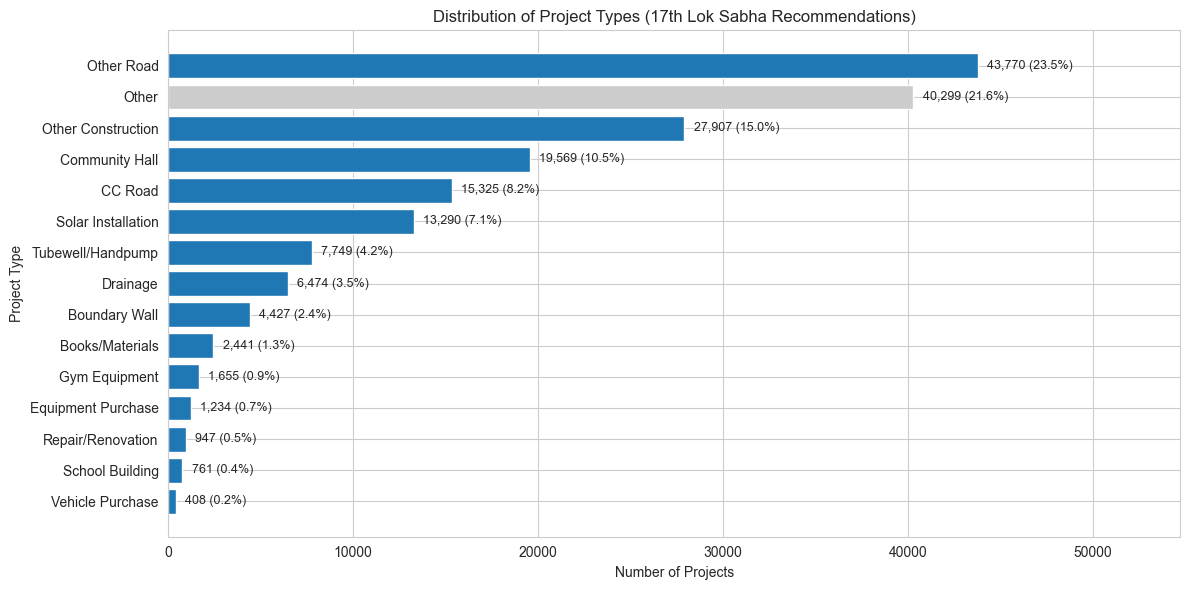

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

type_order = all_type_counts.index.tolist()
colors = [COLORS[0] if t != 'Other' else '#cccccc' for t in type_order]

bars = ax.barh(type_order, all_type_counts.values, color=colors)
ax.set_xlabel('Number of Projects')
ax.set_ylabel('Project Type')
ax.set_title('Distribution of Project Types (17th Lok Sabha Recommendations)')
ax.invert_yaxis()

for bar, count in zip(bars, all_type_counts.values):
    pct = count / len(rec_df) * 100
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlim(0, all_type_counts.max() * 1.25)
plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_08_project_types.png', dpi=150)
plt.show()

## 3. Validate Taxonomy with Samples

In [12]:
print("Sample projects by category:\n")
for ptype in ['Vehicle Purchase', 'CC Road', 'Tubewell/Handpump', 'Community Hall', 'Other']:
    print(f"=== {ptype} ===")
    samples = merged[merged['project_type'] == ptype].head(3)
    for _, row in samples.iterrows():
        desc = str(row['WORK_DESCRIPTION'])[:80] if pd.notna(row['WORK_DESCRIPTION']) else 'N/A'
        print(f"  - {desc}...")
    print()

Sample projects by category:

=== Vehicle Purchase ===
  - Ac  Mobile Doctors Van & primary treatment...
  - Work on procuring fully equipped (AC) Ambulance BS6 vehicle for Valsad Raktdan K...
  - Dist - Junagadh, Taluko - Vanthali, Village - Bhatiya For new dead body van...

=== CC Road ===
  - Laying of CC Road in ST Colony at Gambheerpur  (V), Dubbak (M) , Siddipet Distri...
  - CC road work from crossing to school at Isand village of Kalol taluka...
  - Golthara village of Kalol taluka in Toran vas C.C. Road work...

=== Tubewell/Handpump ===
  - Installing hand pumps at Javol Village, Near Shanabhai Chandubhai Chauhan House ...
  - Installing hand pumps at Javol Village, Near Ramanbhai Raijibhai Chauhan House A...
  - (Year- 2022-23) 
General Work 
Single Phase Bore & Pumping Machinery Near Jashub...

=== Community Hall ===
  - Construction of Reading Room in Potaram (V) of Dubbak (M)...
  - Construction fo Reading Room in Chowdarpally (V) of Dubbak (M)...
  - Construction of Comp

## 4. Project Size by Type

In [13]:
rec_df['amount_lakhs'] = rec_df['RECOMMENDED_AMOUNT'] / 1e5

size_stats = rec_df.groupby('project_type')['amount_lakhs'].agg(['count', 'mean', 'median', 'std']).round(2)
size_stats.columns = ['N', 'Mean (L)', 'Median (L)', 'Std (L)']
size_stats = size_stats.sort_values('Median (L)', ascending=False)

print("Project Size by Type (Rs. Lakhs):")
print(size_stats.to_string())

Project Size by Type (Rs. Lakhs):
                        N  Mean (L)  Median (L)  Std (L)
project_type                                            
Vehicle Purchase      408     15.32       11.00    13.33
School Building       761      9.91        6.00    13.10
Community Hall      19569      6.13        4.95     7.66
Repair/Renovation     947      6.47        4.95    10.56
Equipment Purchase   1234      5.59        4.41    12.60
CC Road             15325      5.08        4.00     5.52
Drainage             6474      5.74        4.00     5.79
Other Construction  27907      5.78        4.00     7.54
Boundary Wall        4427      5.26        3.72     5.61
Gym Equipment        1655      6.88        3.50    24.76
Other Road          43770      5.06        3.38     6.95
Other               40299      3.80        2.05    11.09
Tubewell/Handpump    7749      2.35        1.57     3.06
Books/Materials      2441      3.34        0.50     6.76
Solar Installation  13290      1.55        0.21     3.

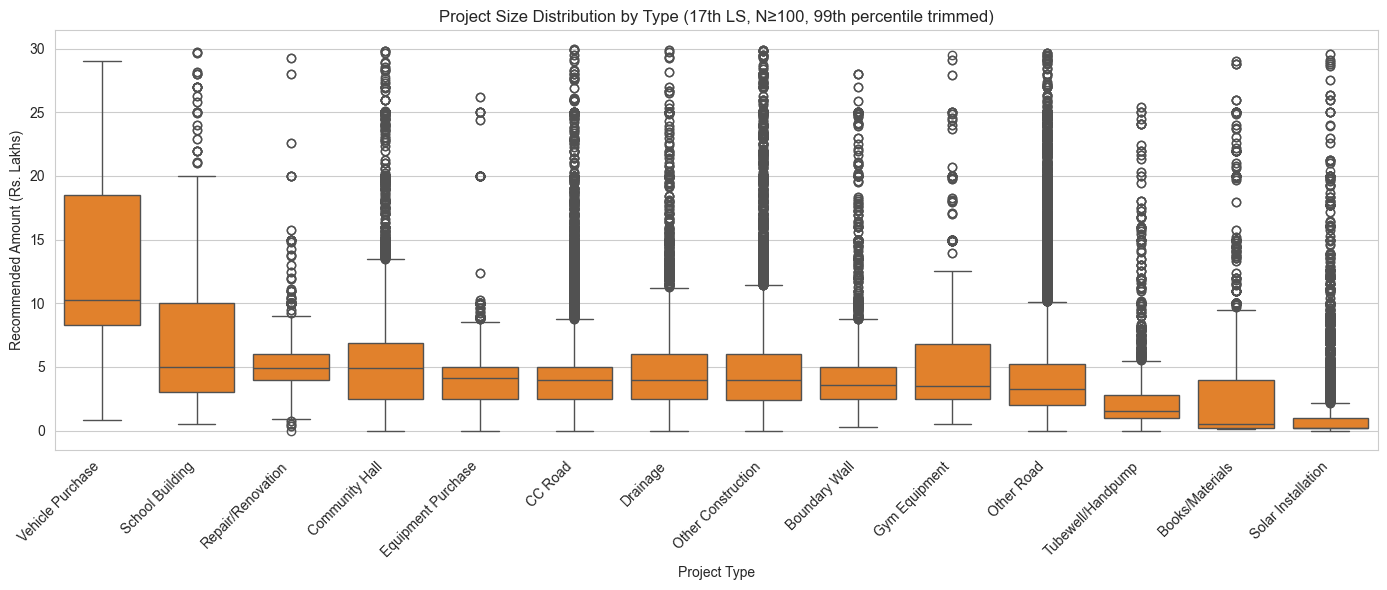

In [14]:
top_types = size_stats[size_stats['N'] >= 100].index.tolist()
if 'Other' in top_types:
    top_types.remove('Other')

fig, ax = plt.subplots(figsize=(14, 6))
plot_data = rec_df[rec_df['project_type'].isin(top_types)].copy()
plot_data = plot_data[plot_data['amount_lakhs'] < plot_data['amount_lakhs'].quantile(0.99)]

type_medians = plot_data.groupby('project_type')['amount_lakhs'].median().sort_values(ascending=False)
order = type_medians.index.tolist()

sns.boxplot(data=plot_data, x='project_type', y='amount_lakhs', order=order, ax=ax, color=COLORS[1])
ax.set_xlabel('Project Type')
ax.set_ylabel('Recommended Amount (Rs. Lakhs)')
ax.set_title('Project Size Distribution by Type (17th LS, N≥100, 99th percentile trimmed)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Completion Time Analysis

In [15]:
completion_stats = merged.groupby('project_type')['days_to_complete'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).round(0)
completion_stats.columns = ['N', 'Mean', 'Median', 'Min', 'Max', 'Std']
completion_stats = completion_stats.sort_values('Median')

print("Completion Time by Project Type (days):")
print(completion_stats.to_string())

Completion Time by Project Type (days):
                        N   Mean  Median  Min   Max    Std
project_type                                              
Other               13089  447.0   493.0    1  2191  296.0
Tubewell/Handpump    2328  421.0   500.0    8  7492  337.0
Vehicle Purchase       99  476.0   542.0    9   914  285.0
Gym Equipment         554  472.0   564.0    1  1336  342.0
Drainage             2214  521.0   574.0    3  1436  261.0
Repair/Renovation     326  509.0   589.0   20   902  249.0
Other Road          13170  521.0   603.0    1  3924  301.0
CC Road              4451  540.0   621.0    1  2197  294.0
Solar Installation   4165  545.0   632.0   24   945  225.0
Other Construction   6790  570.0   657.0    5  3717  279.0
Boundary Wall        1156  582.0   667.0   13  1430  279.0
Equipment Purchase    402  589.0   688.0   23  1282  318.0
Community Hall       3638  637.0   705.0    1  1530  250.0
School Building       162  645.0   710.0   28  1579  262.0
Books/Materials 

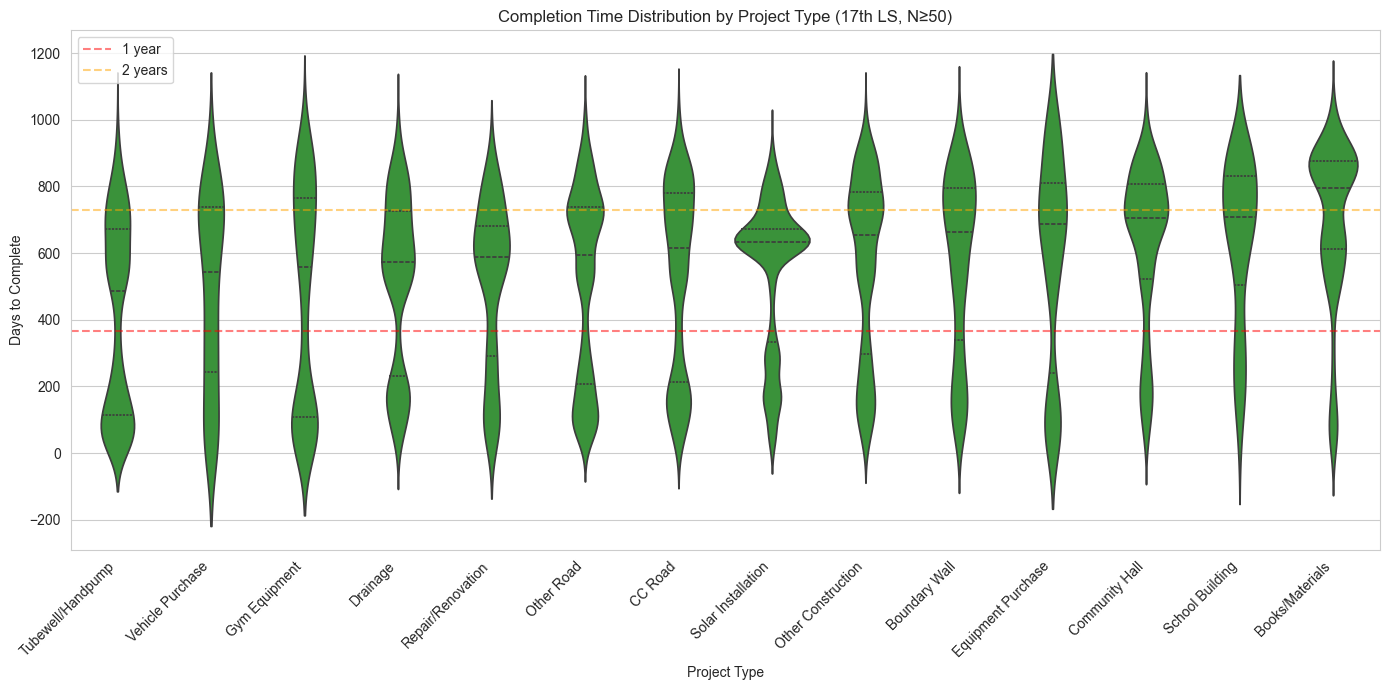

In [16]:
top_types_comp = completion_stats[completion_stats['N'] >= 50].index.tolist()
if 'Other' in top_types_comp:
    top_types_comp.remove('Other')

fig, ax = plt.subplots(figsize=(14, 7))
plot_data = merged[merged['project_type'].isin(top_types_comp)].copy()
plot_data = plot_data[plot_data['days_to_complete'] < plot_data['days_to_complete'].quantile(0.99)]

type_medians = plot_data.groupby('project_type')['days_to_complete'].median().sort_values()
order = type_medians.index.tolist()

sns.violinplot(data=plot_data, x='project_type', y='days_to_complete', order=order, ax=ax, color=COLORS[2], inner='quartile')
ax.set_xlabel('Project Type')
ax.set_ylabel('Days to Complete')
ax.set_title('Completion Time Distribution by Project Type (17th LS, N≥50)')
plt.xticks(rotation=45, ha='right')

ax.axhline(y=365, color='red', linestyle='--', alpha=0.5, label='1 year')
ax.axhline(y=730, color='orange', linestyle='--', alpha=0.5, label='2 years')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_09_completion_time.png', dpi=150)
plt.show()

In [17]:
print("\n=== KEY COMPARISON: Purchase vs Construction ===")
purchase_types = ['Vehicle Purchase', 'Equipment Purchase', 'Books/Materials']
construction_types = ['CC Road', 'Community Hall', 'School Building', 'Other Construction']

purchase_data = merged[merged['project_type'].isin(purchase_types)]['days_to_complete']
construction_data = merged[merged['project_type'].isin(construction_types)]['days_to_complete']

print(f"\nPurchases (N={len(purchase_data):,}):")
print(f"  Median: {purchase_data.median():.0f} days ({purchase_data.median()/365:.1f} years)")
print(f"  Mean: {purchase_data.mean():.0f} days")

print(f"\nConstruction (N={len(construction_data):,}):")
print(f"  Median: {construction_data.median():.0f} days ({construction_data.median()/365:.1f} years)")
print(f"  Mean: {construction_data.mean():.0f} days")

print(f"\n--> Purchases take {purchase_data.median() / construction_data.median() * 100:.0f}% as long as construction!")


=== KEY COMPARISON: Purchase vs Construction ===

Purchases (N=1,305):
  Median: 710 days (1.9 years)
  Mean: 644 days

Construction (N=15,041):
  Median: 669 days (1.8 years)
  Mean: 578 days

--> Purchases take 106% as long as construction!


## 6. Outlier Investigation: Why Do Some Projects Take So Long?

In [18]:
vehicles = merged[merged['project_type'] == 'Vehicle Purchase'].copy()
print(f"Vehicle purchases: {len(vehicles):,}")
print(f"\nCompletion time distribution:")
print(vehicles['days_to_complete'].describe())

print(f"\n\nSlowest vehicle purchases (>1000 days):")
slow_vehicles = vehicles[vehicles['days_to_complete'] > 1000].sort_values('days_to_complete', ascending=False)
for _, row in slow_vehicles.head(5).iterrows():
    desc = str(row['WORK_DESCRIPTION'])[:60] if pd.notna(row['WORK_DESCRIPTION']) else 'N/A'
    print(f"  {row['days_to_complete']:.0f} days: {desc}... ({row['state_name']})")

Vehicle purchases: 99

Completion time distribution:
count     99.000000
mean     476.171717
std      285.313435
min        9.000000
25%      243.000000
50%      542.000000
75%      738.000000
max      914.000000
Name: days_to_complete, dtype: float64


Slowest vehicle purchases (>1000 days):


In [19]:
state_completion = merged.groupby('state_name').agg({
    'days_to_complete': 'median',
    'ACTIVITY_NAME': 'count'
}).rename(columns={'ACTIVITY_NAME': 'N', 'days_to_complete': 'Median Days'})

state_completion = state_completion[state_completion['N'] >= 100].sort_values('Median Days')

print("Completion Time by State (N≥100 projects):")
print("\nFastest states:")
print(state_completion.head(10).to_string())
print("\nSlowest states:")
print(state_completion.tail(10).to_string())

Completion Time by State (N≥100 projects):

Fastest states:
                   Median Days      N
state_name                           
Arunachal Pradesh        222.0    185
Meghalaya                277.0    425
Uttarakhand              292.0   1038
Punjab                   341.0   2957
West Bengal              446.0   2892
Kerala                   467.0   2325
Gujarat                  535.0   4849
Bihar                    537.0   5309
Jharkhand                564.0    641
Uttar Pradesh            573.0  10795

Slowest states:
                  Median Days     N
state_name                         
Odisha                  696.0  1982
Delhi                   714.0   260
Assam                   720.5   422
Himachal Pradesh        721.0   460
Andhra Pradesh          726.0  2219
Maharashtra             728.0  2658
Rajasthan               735.0  2281
Telangana               749.0  1377
Tripura                 769.0   112
Tamil Nadu              773.0  2293


## 7. Summary Table

In [20]:
summary = merged.groupby('project_type').agg({
    'ACTIVITY_NAME': 'count',
    'RECOMMENDED_AMOUNT': 'median',
    'days_to_complete': 'median'
}).rename(columns={
    'ACTIVITY_NAME': 'N Completed',
    'RECOMMENDED_AMOUNT': 'Median Amount (Rs)',
    'days_to_complete': 'Median Days'
})

summary['Median Amount (L)'] = (summary['Median Amount (Rs)'] / 1e5).round(1)
summary['Median Years'] = (summary['Median Days'] / 365).round(1)
summary = summary[['N Completed', 'Median Amount (L)', 'Median Days', 'Median Years']]
summary = summary.sort_values('Median Days')

print("=" * 70)
print("SUMMARY: Project Types by Completion Time")
print("=" * 70)
print(summary.to_string())

SUMMARY: Project Types by Completion Time
                    N Completed  Median Amount (L)  Median Days  Median Years
project_type                                                                 
Other                     13089                2.0        493.0           1.4
Tubewell/Handpump          2328                1.8        499.5           1.4
Vehicle Purchase             99               15.0        542.0           1.5
Gym Equipment               554                3.2        563.5           1.5
Drainage                   2214                4.4        573.5           1.6
Repair/Renovation           326                4.9        589.0           1.6
Other Road                13170                3.5        603.0           1.7
CC Road                    4451                4.6        621.0           1.7
Solar Installation         4165                0.2        632.0           1.7
Other Construction         6790                4.0        657.0           1.8
Boundary Wall         

In [21]:
print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)

fastest = summary['Median Days'].idxmin()
slowest = summary['Median Days'].idxmax()
print(f"\n1. FASTEST: {fastest} ({summary.loc[fastest, 'Median Days']:.0f} days median)")
print(f"   SLOWEST: {slowest} ({summary.loc[slowest, 'Median Days']:.0f} days median)")

vehicle_days = summary.loc['Vehicle Purchase', 'Median Days'] if 'Vehicle Purchase' in summary.index else None
construction_days = summary.loc['CC Road', 'Median Days'] if 'CC Road' in summary.index else None

if vehicle_days and construction_days:
    print(f"\n2. SURPRISE: Vehicle purchases ({vehicle_days:.0f}d) take nearly as long as CC roads ({construction_days:.0f}d)!")
    print("   This suggests completion time is driven more by bureaucratic process than project complexity.")

total_matched = len(merged)
total_rec = len(rec_df)
print(f"\n3. DATA COVERAGE: {total_matched:,} projects with completion times ({total_matched/total_rec*100:.1f}% of recommendations)")

print(f"\n4. OVERALL: Median completion time across all types is {merged['days_to_complete'].median():.0f} days ({merged['days_to_complete'].median()/365:.1f} years)")


KEY TAKEAWAYS

1. FASTEST: Other (493 days median)
   SLOWEST: Books/Materials (795 days median)

2. SURPRISE: Vehicle purchases (542d) take nearly as long as CC roads (621d)!
   This suggests completion time is driven more by bureaucratic process than project complexity.

3. DATA COVERAGE: 53,348 projects with completion times (28.6% of recommendations)

4. OVERALL: Median completion time across all types is 602 days (1.6 years)


In [22]:
print(f"\nFigures saved:")
print(f"  - {DATA_DIR / 'fig_08_project_types.png'}")
print(f"  - {DATA_DIR / 'fig_09_completion_time.png'}")


Figures saved:
  - ../data/fig_08_project_types.png
  - ../data/fig_09_completion_time.png


## 8. Survival Analysis: Accounting for Right-Censoring

The completion time analysis above is **biased**: it only looks at projects that *actually completed*. But ~40% of recommendations never completed. These "censored" observations contain important information.

A better question: **What % of recommendations are completed by 1 or 2 years?**

**Data limitation:** The eSAKSHI portal only has data from FY 2023-24 onwards, so most recommendation dates are from 2023-2024 even though this is 17th LS (2019-2024). We use May 2026 as reference to allow 2+ years for most projects.

In [23]:
REFERENCE_DATE = pd.Timestamp('2026-05-01')

rec_df['rec_date'] = pd.to_datetime(rec_df['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')

print("Recommendation dates by year:")
rec_df['rec_year'] = rec_df['rec_date'].dt.year
year_counts = rec_df['rec_year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"  {int(year)}: {count:,}")

print(f"\nNote: 99% of records are from 2023-2024 due to eSAKSHI portal data availability.")
print(f"This limits survival analysis to 1-2 year horizons.")

Recommendation dates by year:
  2019: 58
  2020: 94
  2021: 67
  2022: 1,286
  2023: 98,767
  2024: 84,943
  2025: 981
  2026: 60

Note: 99% of records are from 2023-2024 due to eSAKSHI portal data availability.
This limits survival analysis to 1-2 year horizons.


In [24]:
comp_lookup_full = comp_df.groupby('ACTIVITY_NAME').agg({
    'ACTUAL_END_DATE': 'first'
}).reset_index()
comp_lookup_full['comp_date'] = pd.to_datetime(comp_lookup_full['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
comp_lookup_full = comp_lookup_full[comp_lookup_full['comp_date'] <= REFERENCE_DATE]

rec_lookup_surv = rec_df[rec_df['rec_date'].notna()].groupby('ACTIVITY_NAME').agg({
    'rec_date': 'first',
    'project_type': 'first'
}).reset_index()

survival_df = rec_lookup_surv.merge(
    comp_lookup_full[['ACTIVITY_NAME', 'comp_date']], 
    on='ACTIVITY_NAME', 
    how='left'
)

survival_df['completed'] = survival_df['comp_date'].notna()
survival_df['days_to_complete'] = (survival_df['comp_date'] - survival_df['rec_date']).dt.days
survival_df['days_available'] = (REFERENCE_DATE - survival_df['rec_date']).dt.days

print(f"Unique activities: {len(survival_df):,}")
print(f"Eventually completed: {survival_df['completed'].sum():,} ({survival_df['completed'].mean()*100:.1f}%)")
print(f"Pending (censored): {(~survival_df['completed']).sum():,} ({(~survival_df['completed']).mean()*100:.1f}%)")

Unique activities: 91,488
Eventually completed: 53,390 (58.4%)
Pending (censored): 38,098 (41.6%)


In [25]:
print("COMPLETION RATES BY TIME POINT (Survival-style)")
print("=" * 70)
print("% of projects that complete within X time, counting ALL recommendations")
print()

for days, label in [(365, '1 year'), (730, '2 years')]:
    eligible = survival_df[survival_df['days_available'] >= days]
    completed_within = (
        eligible['completed'] & 
        (eligible['days_to_complete'] > 0) &
        (eligible['days_to_complete'] <= days)
    ).sum()
    rate = completed_within / len(eligible) * 100 if len(eligible) > 0 else 0
    print(f"{label}: {rate:.1f}% completed")
    print(f"         N eligible: {len(eligible):,}, Completed within: {completed_within:,}")
    print()

COMPLETION RATES BY TIME POINT (Survival-style)
% of projects that complete within X time, counting ALL recommendations

1 year: 19.9% completed
         N eligible: 91,185, Completed within: 18,128

2 years: 42.0% completed
         N eligible: 90,893, Completed within: 38,151



In [26]:
print("COMPLETION RATES BY PROJECT TYPE")
print("=" * 80)
print(f"{'Type':<20} {'N Rec':>8} {'1yr':>8} {'2yr':>8}")
print("-" * 80)

results = []
for ptype in survival_df['project_type'].unique():
    ptype_df = survival_df[survival_df['project_type'] == ptype]
    row = {'Type': ptype, 'N': len(ptype_df)}
    
    for days, label in [(365, '1yr'), (730, '2yr')]:
        eligible = ptype_df[ptype_df['days_available'] >= days]
        if len(eligible) == 0:
            row[label] = np.nan
            continue
        completed = (
            eligible['completed'] &
            (eligible['days_to_complete'] > 0) &
            (eligible['days_to_complete'] <= days)
        ).sum()
        row[label] = completed / len(eligible) * 100
    
    results.append(row)

survival_results = pd.DataFrame(results).sort_values('2yr', ascending=False)
for _, row in survival_results.iterrows():
    yr1 = f"{row['1yr']:.1f}%" if pd.notna(row['1yr']) else 'N/A'
    yr2 = f"{row['2yr']:.1f}%" if pd.notna(row['2yr']) else 'N/A'
    print(f"{row['Type']:<20} {row['N']:>8,} {yr1:>8} {yr2:>8}")

COMPLETION RATES BY PROJECT TYPE
Type                    N Rec      1yr      2yr
--------------------------------------------------------------------------------


Solar Installation      6,610    16.1%    52.7%
Other                  19,948    29.8%    52.3%
Repair/Renovation         473    20.6%    52.3%
Drainage                3,212    20.1%    52.2%
Tubewell/Handpump       3,807    27.8%    51.2%
Gym Equipment             817    28.8%    48.0%
Other Road             21,625    21.3%    43.1%
Equipment Purchase        612    16.8%    40.7%
CC Road                 7,530    19.0%    39.6%
Vehicle Purchase          197    18.9%    37.2%
Boundary Wall           2,173    14.0%    33.4%
Other Construction     13,528    13.9%    32.2%
Books/Materials         1,202     7.5%    30.1%
School Building           366     9.6%    24.0%
Community Hall          9,388     6.9%    21.8%


### Selection Bias in "Median Completion Time"

The earlier "median completion time" analysis (Section 5) only looks at projects that actually completed. This creates **selection bias** - we're only seeing the subset that finished, ignoring the 40%+ that never completed.

In [27]:
print("Completion rates by project type:")
print("=" * 70)
print(f"{'Type':<20} {'All Recs':>10} {'Completed':>10} {'Rate':>8}")
print("-" * 70)

all_type_counts = rec_df.groupby('project_type')['ACTIVITY_NAME'].nunique()
completed_type_counts = merged['project_type'].value_counts()

for ptype in all_type_counts.sort_values(ascending=False).index:
    n_all = all_type_counts.get(ptype, 0)
    n_comp = completed_type_counts.get(ptype, 0)
    rate = n_comp / n_all * 100 if n_all > 0 else 0
    print(f"{ptype:<20} {n_all:>10,} {n_comp:>10,} {rate:>7.1f}%")

total_all = all_type_counts.sum()
total_comp = completed_type_counts.sum()
print("-" * 70)
print(f"{'TOTAL':<20} {total_all:>10,} {total_comp:>10,} {total_comp/total_all*100:>7.1f}%")

Completion rates by project type:
Type                   All Recs  Completed     Rate
----------------------------------------------------------------------


Other Road               21,652     13,170    60.8%
Other                    19,958     13,089    65.6%
Other Construction       13,540      6,790    50.1%
Community Hall            9,393      3,638    38.7%
CC Road                   7,536      4,451    59.1%
Solar Installation        6,614      4,165    63.0%
Tubewell/Handpump         3,812      2,328    61.1%
Drainage                  3,220      2,214    68.8%
Boundary Wall             2,176      1,156    53.1%
Books/Materials           1,207        804    66.6%
Gym Equipment               819        554    67.6%
Equipment Purchase          615        402    65.4%
Repair/Renovation           474        326    68.8%
School Building             370        162    43.8%
Vehicle Purchase            197         99    50.3%
----------------------------------------------------------------------
TOTAL                    91,583     53,348    58.3%


### Cumulative Completion Curves

Plot showing what % of projects complete over time, by project type.

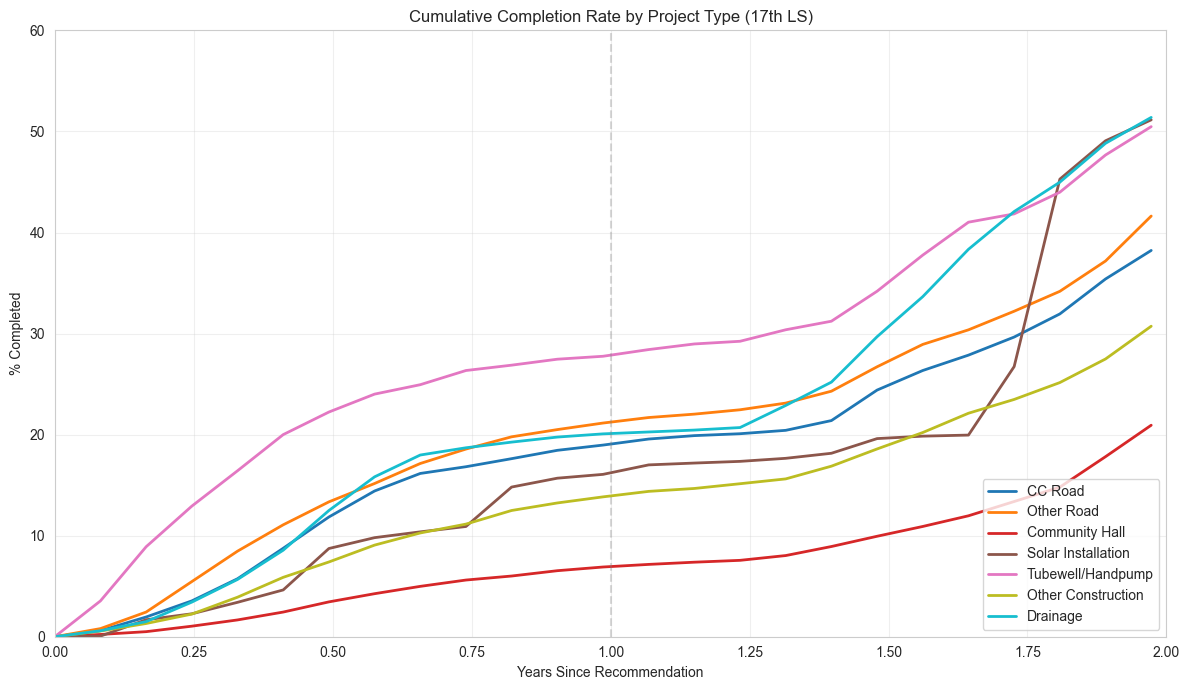

In [28]:
def calc_cumulative_completion(df, max_days=730, step=30):
    """Calculate cumulative completion % over time for each project type."""
    time_points = range(0, max_days + 1, step)
    results = []
    
    for ptype in df['project_type'].unique():
        ptype_df = df[df['project_type'] == ptype]
        
        for days in time_points:
            eligible = ptype_df[ptype_df['days_available'] >= days]
            if len(eligible) < 100:
                continue
            
            completed_by = (
                eligible['completed'] & 
                (eligible['days_to_complete'] > 0) &
                (eligible['days_to_complete'] <= days)
            ).sum()
            
            pct_completed = completed_by / len(eligible) * 100
            
            results.append({
                'project_type': ptype,
                'days': days,
                'pct_completed': pct_completed,
                'n_eligible': len(eligible)
            })
    
    return pd.DataFrame(results)

top_types_km = ['CC Road', 'Other Road', 'Community Hall', 'Solar Installation', 
                'Tubewell/Handpump', 'Other Construction', 'Drainage']
km_df = survival_df[survival_df['project_type'].isin(top_types_km)]
cumulative = calc_cumulative_completion(km_df)

fig, ax = plt.subplots(figsize=(12, 7))

colors_km = plt.cm.tab10(np.linspace(0, 1, len(top_types_km)))
for i, ptype in enumerate(top_types_km):
    ptype_data = cumulative[cumulative['project_type'] == ptype].sort_values('days')
    if len(ptype_data) > 0:
        ax.plot(ptype_data['days'] / 365, ptype_data['pct_completed'], 
                label=ptype, linewidth=2, color=colors_km[i])

ax.set_xlabel('Years Since Recommendation')
ax.set_ylabel('% Completed')
ax.set_title('Cumulative Completion Rate by Project Type (17th LS)')
ax.legend(loc='lower right')
ax.set_xlim(0, 2)
ax.set_ylim(0, 60)
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_10_survival_completion.png', dpi=150)
plt.show()

In [29]:
print("\nFigure saved: fig_10_survival_completion.png")


Figure saved: fig_10_survival_completion.png


## 9. Cross-Body Comparison (LS 17, LS 18, Rajya Sabha)

In [30]:
REFERENCE_DATE = pd.Timestamp('2026-05-26')

def load_and_analyze(archive_path, label):
    """Load data and compute survival stats for a given body."""
    with tarfile.open(archive_path, 'r:gz') as tar:
        csv_member = [m for m in tar.getmembers() if m.name.endswith('.csv') and not m.name.startswith('._')][0]
        df = pd.read_csv(tar.extractfile(csv_member), low_memory=False, on_bad_lines='skip')
    
    rec_df = df[df['RECOMMENDATION_DATE'].notna()].copy()
    comp_df = df[df['ACTUAL_END_DATE'].notna()].copy()
    
    rec_df['rec_date'] = pd.to_datetime(rec_df['RECOMMENDATION_DATE'], format='%d-%b-%Y', errors='coerce')
    comp_df['comp_date'] = pd.to_datetime(comp_df['ACTUAL_END_DATE'], format='%d-%b-%Y', errors='coerce')
    comp_df = comp_df[comp_df['comp_date'] <= REFERENCE_DATE]
    
    rec_lookup = rec_df[rec_df['rec_date'].notna()].groupby('ACTIVITY_NAME').agg({'rec_date': 'first'}).reset_index()
    comp_lookup = comp_df.groupby('ACTIVITY_NAME').agg({'comp_date': 'first'}).reset_index()
    
    surv = rec_lookup.merge(comp_lookup, on='ACTIVITY_NAME', how='left')
    surv['completed'] = surv['comp_date'].notna()
    surv['days_to_complete'] = (surv['comp_date'] - surv['rec_date']).dt.days
    surv['days_available'] = (REFERENCE_DATE - surv['rec_date']).dt.days
    
    results = {'Body': label, 'N': len(surv)}
    
    for days, dlabel in [(365, '1yr'), (548, '18mo'), (730, '2yr')]:
        eligible = surv[surv['days_available'] >= days]
        if len(eligible) >= 100:
            completed_within = (eligible['completed'] & (eligible['days_to_complete'] > 0) & (eligible['days_to_complete'] <= days)).sum()
            results[dlabel] = completed_within / len(eligible) * 100
        else:
            results[dlabel] = np.nan
    
    return results

comparison = []
for archive, label in [
    (DATA_DIR / 'works_ls17.csv.tar.gz', '17th LS'),
    (DATA_DIR / 'works_ls18.csv.tar.gz', '18th LS'),
    (DATA_DIR / 'works_rs.csv.tar.gz', 'Rajya Sabha'),
]:
    comparison.append(load_and_analyze(archive, label))

comparison_df = pd.DataFrame(comparison)
print("CROSS-BODY COMPLETION RATES (% completed by time point)")
print("=" * 65)
print(comparison_df.round(1).to_string(index=False))

CROSS-BODY COMPLETION RATES (% completed by time point)
       Body     N  1yr  18mo  2yr
    17th LS 91488 19.9  25.7 42.0
    18th LS 67437 27.8  52.6  NaN
Rajya Sabha 21957 32.5  43.5 54.6
